In [5]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal
load_dotenv()

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [6]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [7]:




def show_eq(state:QuadState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']}".replace("+ -", "- ")
    return {
        "equation":equation
    }

def cal_discriminant(state:QuadState):
    discriminant=(state['b']**2-4*state['a']*state['c'])
    return {"discriminant":discriminant}

def real_roots(state:QuadState):
    root1=(-state['b']+state["discriminant"]**0.5)/(2*state['a'])
    root2=(-state['b']-state["discriminant"]**0.5)/(2*state['a'])
    result=f"This Equation has two real roots which are {round(root1,2)} and {round(root2,2)}"
    return {"result":result}

def repeated_roots(state:QuadState):
    root=(-state['b']+state["discriminant"]**0.5)/(2*state['a'])
    result=f"This Equation has repeated root which is {round(root,2)}"
    return {"result":result}


def no_roots(state:QuadState):
    result=f"This Equation has no roots."
    return {"result":result}

def check_condition(state:QuadState)->Literal["real_roots","repeated_roots","no_roots"]:
    if(state["discriminant"]>0):
        return "real_roots"
    elif(state["discriminant"]==0):
        return "repeated_roots"
    else:
        return "no_roots"

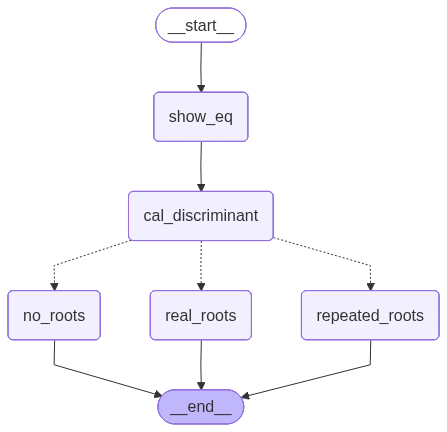

In [8]:
graph=StateGraph(QuadState)
graph.add_node("show_eq",show_eq)
graph.add_node("cal_discriminant", cal_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_roots", no_roots)


graph.add_edge(START,"show_eq")
graph.add_edge("show_eq","cal_discriminant")
graph.add_conditional_edges("cal_discriminant",check_condition)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_roots",END)
workflow=graph.compile()
workflow

In [ ]:
result=workflow.invoke({"a":1,"b":98,"c":5})
print(result["result"])
print(result["equation"])